In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import pandas as pd

In [2]:
with open("xf-naca001264-il-1000000.txt") as file:
    raw_data_string_rows = file.readlines()

for i in range(15):
    print(raw_data_string_rows[i])

  

       XFOIL         Version 6.96

  

 Calculated polar for: NACA 0012-64                                    

  

 1 1 Reynolds number fixed          Mach number fixed         

  

 xtrf =   1.000 (top)        1.000 (bottom)  

 Mach =   0.000     Re =     1.000 e 6     Ncrit =   9.000

  

   alpha    CL        CD       CDp       CM     Top_Xtr  Bot_Xtr

  ------ -------- --------- --------- -------- -------- --------

 -19.250  -1.1202   0.11676   0.11433  -0.0124   1.0000   0.0145

 -19.000  -1.1663   0.10394   0.10134  -0.0194   1.0000   0.0144

 -18.750  -1.2069   0.09241   0.08963  -0.0258   1.0000   0.0144



In [3]:
for i in range(13):
    print(raw_data_string_rows[i])

  

       XFOIL         Version 6.96

  

 Calculated polar for: NACA 0012-64                                    

  

 1 1 Reynolds number fixed          Mach number fixed         

  

 xtrf =   1.000 (top)        1.000 (bottom)  

 Mach =   0.000     Re =     1.000 e 6     Ncrit =   9.000

  

   alpha    CL        CD       CDp       CM     Top_Xtr  Bot_Xtr

  ------ -------- --------- --------- -------- -------- --------

 -19.250  -1.1202   0.11676   0.11433  -0.0124   1.0000   0.0145



In [4]:
for i in range(10):
    print(raw_data_string_rows[-i])

  

  18.750   1.2104   0.09223   0.08945   0.0254   0.0144   1.0000

  18.500   1.2437   0.08221   0.07925   0.0311   0.0143   1.0000

  18.250   1.2682   0.07399   0.07087   0.0357   0.0144   1.0000

  18.000   1.2862   0.06720   0.06393   0.0394   0.0144   1.0000

  17.750   1.2991   0.06160   0.05817   0.0423   0.0145   1.0000

  17.500   1.3072   0.05697   0.05340   0.0444   0.0146   1.0000

  17.250   1.3135   0.05287   0.04917   0.0460   0.0147   1.0000

  17.000   1.3323   0.04763   0.04377   0.0474   0.0149   1.0000

  16.750   1.3415   0.04384   0.03986   0.0479   0.0152   1.0000



In [5]:
raw_data_string_rows_trimmed_header = raw_data_string_rows[13:]

for i in range(10):
    print(raw_data_string_rows_trimmed_header[i])

 -19.000  -1.1663   0.10394   0.10134  -0.0194   1.0000   0.0144

 -18.750  -1.2069   0.09241   0.08963  -0.0258   1.0000   0.0144

 -18.500  -1.2395   0.08249   0.07954  -0.0313   1.0000   0.0144

 -18.250  -1.2650   0.07414   0.07102  -0.0360   1.0000   0.0144

 -18.000  -1.2831   0.06734   0.06406  -0.0398   1.0000   0.0145

 -17.750  -1.2957   0.06179   0.05836  -0.0426   1.0000   0.0145

 -17.500  -1.3040   0.05713   0.05356  -0.0447   1.0000   0.0146

 -17.250  -1.3131   0.05267   0.04897  -0.0464   1.0000   0.0147

 -17.000  -1.3309   0.04759   0.04372  -0.0477   1.0000   0.0150

 -16.750  -1.3396   0.04386   0.03989  -0.0482   1.0000   0.0152



In [6]:
raw_data_string_rows_trimmed_header[0]

' -19.000  -1.1663   0.10394   0.10134  -0.0194   1.0000   0.0144\n'

In [7]:
table = []
for string_row in raw_data_string_rows_trimmed_header:
    row = []
    splitted_string_row = string_row.split(" ")
    for string_item in splitted_string_row:
        if string_item != "":
            row.append(float(string_item.strip()))
    table.append(row.copy())
table

[[-19.0, -1.1663, 0.10394, 0.10134, -0.0194, 1.0, 0.0144],
 [-18.75, -1.2069, 0.09241, 0.08963, -0.0258, 1.0, 0.0144],
 [-18.5, -1.2395, 0.08249, 0.07954, -0.0313, 1.0, 0.0144],
 [-18.25, -1.265, 0.07414, 0.07102, -0.036, 1.0, 0.0144],
 [-18.0, -1.2831, 0.06734, 0.06406, -0.0398, 1.0, 0.0145],
 [-17.75, -1.2957, 0.06179, 0.05836, -0.0426, 1.0, 0.0145],
 [-17.5, -1.304, 0.05713, 0.05356, -0.0447, 1.0, 0.0146],
 [-17.25, -1.3131, 0.05267, 0.04897, -0.0464, 1.0, 0.0147],
 [-17.0, -1.3309, 0.04759, 0.04372, -0.0477, 1.0, 0.015],
 [-16.75, -1.3396, 0.04386, 0.03989, -0.0482, 1.0, 0.0152],
 [-16.5, -1.3413, 0.04112, 0.03706, -0.0482, 1.0, 0.0154],
 [-16.25, -1.338, 0.03901, 0.03488, -0.048, 1.0, 0.0157],
 [-16.0, -1.332, 0.03725, 0.03305, -0.0476, 1.0, 0.0159],
 [-15.75, -1.3252, 0.03564, 0.03138, -0.0471, 1.0, 0.0162],
 [-15.5, -1.3176, 0.03417, 0.02983, -0.0463, 1.0, 0.0165],
 [-15.25, -1.3097, 0.03278, 0.02835, -0.0454, 1.0, 0.0168],
 [-15.0, -1.301, 0.03149, 0.02698, -0.0444, 1.0, 0.0171

In [8]:
table_header = ["alpha", "CL", "CD", "CDp", "CM", "Top_Xtr", "Bot_Xtr"]
df = pd.DataFrame(table, columns=table_header, dtype=float)
df.head()

,alpha,CL,CD,CDp,CM,Top_Xtr,Bot_Xtr
0,-19.00,-1.1663,0.10394,0.10134,-0.0194,1.0,0.0144
1,-18.75,-1.2069,0.09241,0.08963,-0.0258,1.0,0.0144
2,-18.50,-1.2395,0.08249,0.07954,-0.0313,1.0,0.0144
3,-18.25,-1.2650,0.07414,0.07102,-0.0360,1.0,0.0144
4,-18.00,-1.2831,0.06734,0.06406,-0.0398,1.0,0.0145


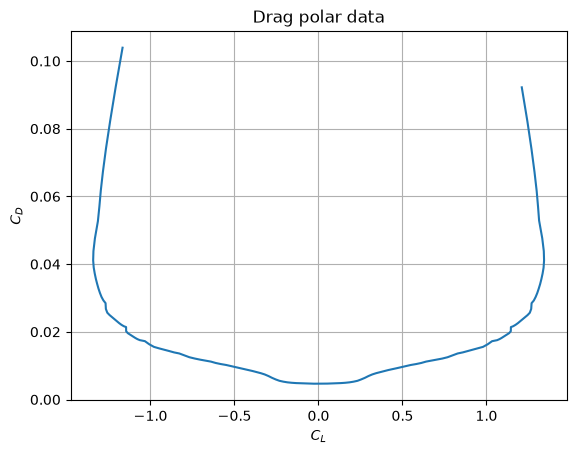

In [9]:
import matplotlib.pyplot as plt

plt.plot(df["CL"], df["CD"])
plt.grid()
plt.xlabel("$C_L$")
plt.ylabel("$C_D$")
plt.title("Drag polar data")
plt.show()

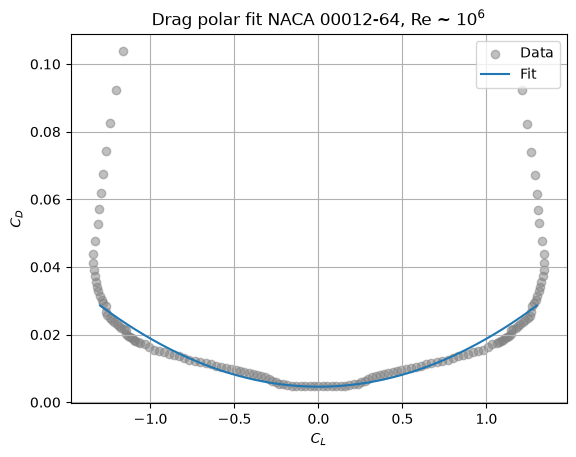

In [10]:
mask = df["CD"] < 0.04

model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model.fit(df[mask]["CL"].values.reshape(-1, 1), df[mask]["CD"])
x_predict = np.linspace(-1.3, 1.3, 1000).reshape(-1, 1)
y_predict = model.predict(x_predict)

plt.scatter(df["CL"], df["CD"], label="Data", color="gray", alpha=0.5)
plt.plot(x_predict.reshape(-1), y_predict, label=f"Fit")
plt.grid()
plt.xlabel("$C_L$")
plt.ylabel("$C_D$")
plt.legend()
plt.title("Drag polar fit NACA 00012-64, Re ~ $10^6$")
plt.savefig("drag_polar.png")
plt.show()

In [11]:
reg = model.named_steps["linearregression"]
K2, K1 = reg.coef_[1:3]
CD0 = reg.intercept_

print("K1:", K1)
print("K2:", K2)
print("CD0:", CD0)

K1: 0.014200598840310306
K2: -1.559613656009276e-05
CD0: 0.004590508724648499


In [14]:
print(df.iloc[np.argmax(df["CL"] / df["CD"])])

alpha      9.00000
CL         0.97960
CD         0.01555
CDp        0.00970
CM         0.00010
Top_Xtr    0.02800
Bot_Xtr    0.99620
Name: 112, dtype: float64
